[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T03_B_garch_volatility_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl arch
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Tema 3B — Agrupamiento de Volatilidad, Heterocedasticidad Condicional y Efecto Apalancamiento

**Curso Complementario · Macroeconomía Avanzada (MAV)**

Los precios de los activos financieros y las series temporales macroeconómicas exhiben una regularidad empírica fundamental documentada originalmente por Mandelbrot (1963): los movimientos de gran magnitud tienden a estar seguidos por movimientos grandes (de cualquier signo), mientras que las variaciones moderadas son seguidas por fluctuaciones moderadas. La volatilidad no es constante a lo largo del tiempo; se **agrupa** en regímenes bien definidos de alta y baja varianza.

En este cuaderno transitamos desde la validación computacional controlada hacia la realidad macroeconómica empírica. Comenzamos examinando la formulación canónica **GARCH(1,1)** de Bollerslev (1986) y su extensión multivariada, el modelo de **Correlación Condicional Dinámica (DCC)** de Engle (2002). A continuación, confrontamos los límites del GARCH estándar: ¿por qué fracasa la heterocedasticidad condicional al estimarse sobre agregados macroeconómicos trimestrales y por qué la simetría lineal resulta insostenible en los mercados financieros?

Para responder a este enigma, fundamentamos la asimetría financiera en dos canales teóricos esenciales:
1. **La Hipótesis del Apalancamiento Financiero (Black 1976, Christie 1982)**: Cuando el valor del capital accionario disminuye, el valor nominal de la deuda permanece constante, lo que provoca un incremento inmediato en la razón deuda-capital ($D/E$). Este mayor apalancamiento amplifica el riesgo del capital residual, disparando la volatilidad de los rendimientos futuros.
2. **La Hipótesis de Retroalimentación de Volatilidad (Campbell & Hentschel 1992, Bekaert & Wu 2000)**: Si el riesgo de volatilidad se compensa en el mercado, un aumento anticipado en la turbulencia eleva la tasa de descuento requerida por los inversores reacios al riesgo. Para garantizar mayores retornos esperados hacia adelante, el precio actual del activo debe caer abruptamente. De este modo, los rendimientos negativos y los estallidos de volatilidad se retroalimentan mutuamente.

Sometemos estas hipótesis a contraste empírico utilizando más de 30 años de cotizaciones diarias del Índice de Volatilidad CBOE (`VIXCLS.csv`), estimamos especificaciones asimétricas **GJR-GARCH** (Glosten, Jagannathan & Runkle 1993) y **EGARCH** (Nelson 1991), derivamos la **Curva de Impacto de las Noticias** (Engle & Ng 1993) y evaluamos la estabilidad del proceso durante crisis sistémicas (la quiebra de Lehman Brothers en 2008 vs. el choque COVID-19 en 2020).

## Especificaciones Econométricas: GARCH, GJR-GARCH y DCC

Escribimos una innovación de rendimiento o variación logarítmica de media cero como un choque reescalado, $u_t = \sigma_t\,\varepsilon_t$, con ruido blanco estándar $\varepsilon_t \sim \text{i.i.d.}(0, 1)$.

### 1. GARCH(1,1) Simétrico (Bollerslev, 1986)
La varianza condicional sigue una recursión autorregresiva y de medias móviles sobre las innovaciones al cuadrado:
$$ \sigma_t^2 = \omega + \alpha\,u_{t-1}^2 + \beta\,\sigma_{t-1}^2, \qquad \omega > 0, \ \alpha \ge 0, \ \beta \ge 0. $$
La **persistencia** de los choques de volatilidad es $\alpha + \beta$. La estacionariedad en covarianza exige $\alpha + \beta < 1$, bajo la cual la varianza incondicional de largo plazo es:
$$ \bar\sigma^2 = \frac{\omega}{1 - \alpha - \beta}. $$
El vector de parámetros $\theta = (\omega, \alpha, \beta)$ se estima mediante **Cuasi-Máxima Verosimilitud Gaussiana (QMLE)**:
$$ \ell(\theta) = -\frac{1}{2} \sum_{t=1}^T \left[ \log(2\pi) + \log\sigma_t^2 + \frac{u_t^2}{\sigma_t^2} \right]. $$

### 2. GJR-GARCH(1,1,1) Asimétrico (Glosten, Jagannathan & Runkle, 1993)
Para capturar las asimetrías de apalancamiento y retroalimentación, el modelo GJR-GARCH introduce una variable indicadora para las innovaciones negativas:
$$ \sigma_t^2 = \omega + \left(\alpha + \gamma\,\mathbb{I}_{\{u_{t-1} < 0\}}\right) u_{t-1}^2 + \beta\,\sigma_{t-1}^2, $$
donde $\mathbb{I}_{\{u_{t-1} < 0\}} = 1$ si $u_{t-1} < 0$ y $0$ en caso contrario. Si $\gamma > 0$, las noticias negativas generan un impacto sobre la volatilidad estrictamente superior al de las noticias positivas ($\alpha + \gamma$ frente a $\alpha$). Bajo normalidad condicional, la estacionariedad requiere $\alpha + \frac{1}{2}\gamma + \beta < 1$, produciendo una varianza incondicional $\bar\sigma^2 = \omega / (1 - \alpha - \frac{1}{2}\gamma - \beta)$.

### 3. Correlación Condicional Dinámica Multivariada (DCC de Engle, 2002)
Para un vector de $K$ rendimientos, el modelo DCC separa las volatilidades individuales de la dinámica de correlación temporal. Estandarizando los residuos univariados por sus desviaciones típicas condicionales, $\eta_{t} = D_t^{-1} u_t$ con $D_t = \operatorname{diag}(\sigma_{1,t}, \dots, \sigma_{K,t})$, la cuasi-correlación $Q_t$ sigue el proceso:
$$ Q_t = (1 - a - b)\,\bar Q + a\,\eta_{t-1}\eta_{t-1}' + b\,Q_{t-1}, \qquad R_t = \operatorname{diag}(Q_t)^{-1/2}\,Q_t\,\operatorname{diag}(Q_t)^{-1/2}, $$
donde $\bar Q$ es la matriz de correlación incondicional muestral de $\eta_t$. La matriz completa de covarianzas condicionales es $H_t = D_t R_t D_t$. La estacionariedad de las correlaciones requiere $a + b < 1$.

### Intuición Económica y Econométrica

1. **Agrupamiento de Volatilidad**: La recursión $\alpha\,u_{t-1}^2 + \beta\,\sigma_{t-1}^2$ formaliza la persistencia temporal. Un choque inesperado ayer ($u_{t-1}^2$) incrementa la varianza de hoy a través de $\alpha$, mientras que la varianza previa se propaga hacia el futuro mediante $\beta$. Cuando $\alpha + \beta \approx 0,95$ (típico en finanzas empíricas), los choques de volatilidad tienen una vida media prolongada: las etapas de calma persisten y los episodios de crisis duran semanas o meses.
2. **Contagio Dinámico**: En la formulación DCC, la correlación no es una constante estática. El parámetro $a$ cuantifica qué tan rápido reacciona el comovimiento a choques conjuntos, mientras que $b$ gobierna la memoria de la correlación. En episodios de pánico financiero, las correlaciones convergen hacia la unidad debido a que presiones sistémicas de liquidez fuerzan ventas simultáneas en todas las clases de activos.
3. **La Limitación de la Simetría Lineal**: Nótese que el GARCH(1,1) estándar eleva al cuadrado el choque rezagado $u_{t-1}^2$, tratando una subida del $+5\%$ de manera idéntica a un desplome del $-5\%$. No obstante, en los mercados accionarios las caídas abruptas desatan pánico e incrementan el apalancamiento, mientras que las alzas graduales apaciguan la volatilidad. Los modelos asimétricos corrigen esta deficiencia modelando explícitamente la **Curva de Impacto de las Noticias**.

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from _datos import DATOS, crecimiento
from puremacro.garch import garch11_fit, dcc_fit, GARCH11Result, DCCResult
from puremacro.reports import df_to_latex, df_to_markdown, df_to_typst

## 1. GARCH(1,1) Univariado: Validación Computacional de Recuperación de Parámetros

Antes de confrontar series temporales empíricas, implementamos una prueba de control computacional tipo Monte Carlo. Simulamos $T = 2.000$ observaciones diarias a partir de un proceso generador de datos (DGP) con valores conocidos: $\omega = 0,05$, $\alpha = 0,10$ y $\beta = 0,85$ (persistencia implícita $\alpha + \beta = 0,95$). Estimamos los coeficientes mediante QMLE gaussiana y verificamos que el estimador recupera los parámetros estructurales y reproduce la trayectoria de la volatilidad condicional latente $\sigma_t$.

In [3]:
def simulate_garch(rng, T, omega, alpha, beta):
    eps = np.zeros(T)
    sigma2 = np.zeros(T)
    sigma2[0] = omega / max(1e-8, 1.0 - alpha - beta)
    for t in range(1, T):
        sigma2[t] = omega + alpha * eps[t - 1] ** 2 + beta * sigma2[t - 1]
        eps[t] = np.sqrt(sigma2[t]) * rng.standard_normal()
    idx = pd.date_range("1990-01-01", periods=T, freq="MS")
    return pd.Series(eps, index=idx), np.sqrt(sigma2)

rng = np.random.default_rng(23)
OMEGA, ALPHA, BETA = 0.05, 0.10, 0.85          # true persistence = 0.95
T = 2000
r, sigma_true = simulate_garch(rng, T, OMEGA, ALPHA, BETA)

fit = garch11_fit(r)
print("--- GARCH(1,1) Resumen del Ajuste ---")
print(fit.summary())
print("\n--- Exportación de Tabla de Publicación (Markdown) ---")
print(fit.to_markdown())

assert fit.converged
assert fit.persistence < 1.0                              # stationary
assert abs(fit.persistence - (ALPHA + BETA)) < 0.05       # persistence recovered
assert abs(fit.alpha - ALPHA) < 0.05                      # alpha recovered
assert abs(fit.beta - BETA) < 0.07                        # beta recovered
assert (fit.sigma > 0).all() and len(fit.sigma) == T
corr_sigma = np.corrcoef(fit.sigma.values[1:], sigma_true[1:])[0, 1]
print(f"corr(fitted sigma, true sigma) = {corr_sigma:.3f}")
assert corr_sigma > 0.90                                  # tracks latent vol

--- GARCH(1,1) Resumen del Ajuste ---
GARCH(1,1) fit
  ω                 : 0.049127
  α                 : 0.0918
  β                 : 0.8554
  persistence (α+β) : 0.9472
  log-lik           : -2695.7689
  converged         : True


--- Exportación de Tabla de Publicación (Markdown) ---
|   parameter |        value |
|-------------|--------------|
|       omega |     0.049127 |
|       alpha |     0.091796 |
|        beta |     0.855389 |
| persistence |     0.947185 |
|      loglik | -2695.768911 |
|       n_obs |         2000 |
|   converged |         True |
corr(fitted sigma, true sigma) = 1.000


### Interpretación Econométrica: Consistencia y Seguimiento del Estado Latente

La optimización numérica por QMLE gaussiana converge de manera limpia y recupera con precisión los parámetros estructurales del proceso generador:
- El coeficiente ARCH estimado $\hat\alpha \approx 0,09$ indica que una innovación estandarizada transmite aproximadamente el 9% de su magnitud cuadrática directamente a la varianza del período inmediato posterior.
- El coeficiente GARCH estimado $\hat\beta \approx 0,85$ constata que el 85% de la varianza condicional previa perdura en el período siguiente.
- La persistencia estimada $\hat\alpha + \hat\beta \approx 0,95$ se ubica estrictamente por debajo de la unidad, ratificando la estacionariedad en covarianza con una varianza incondicional finita $\bar\sigma = \sqrt{\omega / (1 - \alpha - \beta)}$.

Dado que la volatilidad latente $\sigma_t$ es inherentemente inobservable en los mercados empíricos, el criterio rector de desempeño consiste en evaluar la capacidad del filtro para reconstruir el estado no observable. La correlación entre la trayectoria estimada $\hat\sigma_t$ y la volatilidad latente verdadera supera el $0,90$, confirmando que la QMLE gaussiana rescata fielmente la heterocedasticidad condicional basándose exclusivamente en los rendimientos observables.

## 2. Correlación Condicional Dinámica (DCC): Comovimiento Financiero Variable en el Tiempo

Los modelos GARCH univariados capturan el agrupamiento de volatilidad en un activo aislado, pero el análisis macroeconómico y la estabilidad financiera exigen modelar el comovimiento conjunto entre mercados. Los supuestos de correlación constante fallan estrepitosamente en episodios de estrés sistémico, ya que la correlación entre activos se dispara cuando la liquidez se contrae.

A continuación simulamos un sistema bivariado DCC(1,1) donde cada activo sigue su propio proceso GARCH(1,1), mientras que su correlación condicional $\rho_t$ obedece a la recursión con reversión a la media de Engle (2002) alrededor de un nivel base $\bar\rho = 0,45$, con parámetros de persistencia $a = 0,05$ y $b = 0,90$ (persistencia total $a + b = 0,95$). Estimamos el modelo DCC en dos etapas y contrastamos la recuperación de la correlación latente.

In [4]:
def simulate_dcc(rng, T, a, b, rho_bar):
    # Standardized innovations e_t and the true rho_t from a DCC(1,1)
    Qbar = np.array([[1.0, rho_bar], [rho_bar, 1.0]])
    Q = Qbar.copy()
    e = np.empty((T, 2))
    rho_true = np.empty(T)
    e_prev = np.zeros(2)
    for t in range(T):
        if t > 0:
            Q = (1 - a - b) * Qbar + a * np.outer(e_prev, e_prev) + b * Q
        d = np.sqrt(np.diag(Q))
        R = Q / np.outer(d, d)
        rho_true[t] = R[0, 1]
        e_prev = np.linalg.cholesky(R) @ rng.standard_normal(2)
        e[t] = e_prev
    return e, rho_true

def garch_vol(zcol, omega, alpha, beta):
    Tt = len(zcol)
    s2 = np.empty(Tt)
    u = np.empty(Tt)
    s2[0] = omega / (1.0 - alpha - beta)
    u[0] = np.sqrt(s2[0]) * zcol[0]
    for t in range(1, Tt):
        s2[t] = omega + alpha * u[t - 1] ** 2 + beta * s2[t - 1]
        u[t] = np.sqrt(s2[t]) * zcol[t]
    return u

A_DCC, B_DCC = 0.05, 0.90                       # true DCC persistence = 0.95
rng2 = np.random.default_rng(42)
Td = 1800
e, rho_true = simulate_dcc(rng2, Td, A_DCC, B_DCC, rho_bar=0.45)
uA = garch_vol(e[:, 0], 0.05, 0.08, 0.90)
uB = garch_vol(e[:, 1], 0.03, 0.12, 0.84)
idx_d = pd.date_range("2005-01-03", periods=Td, freq="B")
panel = pd.DataFrame({"Asset A": uA, "Asset B": uB}, index=idx_d)

dcc = dcc_fit(panel)
print("--- DCC(1,1) Resumen del Ajuste ---")
print(dcc.summary())
print("\n--- Exportación de Tabla de Publicación DCC (Markdown) ---")
print(dcc.to_markdown())

assert dcc.converged
assert 0.0 <= dcc.a <= 1.0 and 0.0 <= dcc.b <= 1.0
assert dcc.a + dcc.b < 1.0                                # stationary correlation
assert dcc.R.shape == (Td, 2, 2) and dcc.H.shape == (Td, 2, 2)
assert dcc.sigma.shape == (Td, 2)
rho_hat = dcc.R[:, 0, 1]
assert np.all(np.abs(rho_hat) <= 1.0 + 1e-8)             # valid correlations
track = np.corrcoef(rho_hat, rho_true)[0, 1]
print(f"corr(rho_hat, rho_true) = {track:.3f}")
assert track > 0.90                                      # recovers latent corr path
assert len(dcc.garch_params) == 2
assert all(0.0 < gp["persistence"] < 1.0 for gp in dcc.garch_params)

--- DCC(1,1) Resumen del Ajuste ---
DCC(1,1) fit
  series (n)        : 2
  observations (T)  : 1800
  a                 : 0.0648
  b                 : 0.8847
  a + b             : 0.9496
  log-lik (DCC)     : +309.5009
  converged         : True


--- Exportación de Tabla de Publicación DCC (Markdown) ---
|  series |   parameter |      value |
|---------|-------------|------------|
|     DCC |           a |   0.064849 |
|     DCC |           b |   0.884741 |
|     DCC |         a+b |   0.949589 |
|     DCC |      loglik | 309.500907 |
|     DCC |       n_obs |       1800 |
|     DCC |   converged |       True |
| Asset A |       omega |   0.049563 |
| Asset A |       alpha |   0.075548 |
| Asset A |        beta |   0.904164 |
| Asset A | persistence |   0.979713 |
| Asset B |       omega |   0.034081 |
| Asset B |       alpha |   0.116215 |
| Asset B |        beta |   0.845788 |
| Asset B | persistence |   0.962003 |
corr(rho_hat, rho_true) = 0.998


### Estimación en Dos Etapas y Persistencia del Comovimiento

La metodología de estimación en dos etapas de Engle (2002) opera de manera secuencial:
1. **Etapa 1 (Des-GARCHing Univariado)**: Ajusta procesos GARCH(1,1) independientes para cada serie, produciendo las volatilidades condicionales $\hat\sigma_{i,t}$ y los residuos estandarizados $\hat\eta_{i,t} = u_{i,t} / \hat\sigma_{i,t}$.
2. **Etapa 2 (Correlación Dinámica)**: Maximiza la función de verosimilitud de correlación condicionada a los residuos estandarizados para obtener los parámetros $(\hat a, \hat b)$.

La persistencia estimada de la correlación $\hat a + \hat b \approx 0,95$ replica la estructura del DGP. El parámetro $\hat a$ mide la sensibilidad del comovimiento ante choques conjuntos contemporáneos, mientras que $\hat b$ refleja la inercia temporal. La correlación estimada $\hat\rho_t = R_{t, 12}$ sigue la trayectoria latente con una correlación empírica $r > 0,99$, demostrando la capacidad del filtro DCC para discriminar entre regímenes de diversificación habitual y episodios de contagio financiero.

### Figura 1: Envolventes Dinámicas de Volatilidad y Agrupamiento de Regímenes
La envolvente condicional $\pm 2\hat\sigma_t$ se expande durante episodios de turbulencia y se contrae en períodos de calma prolongada.

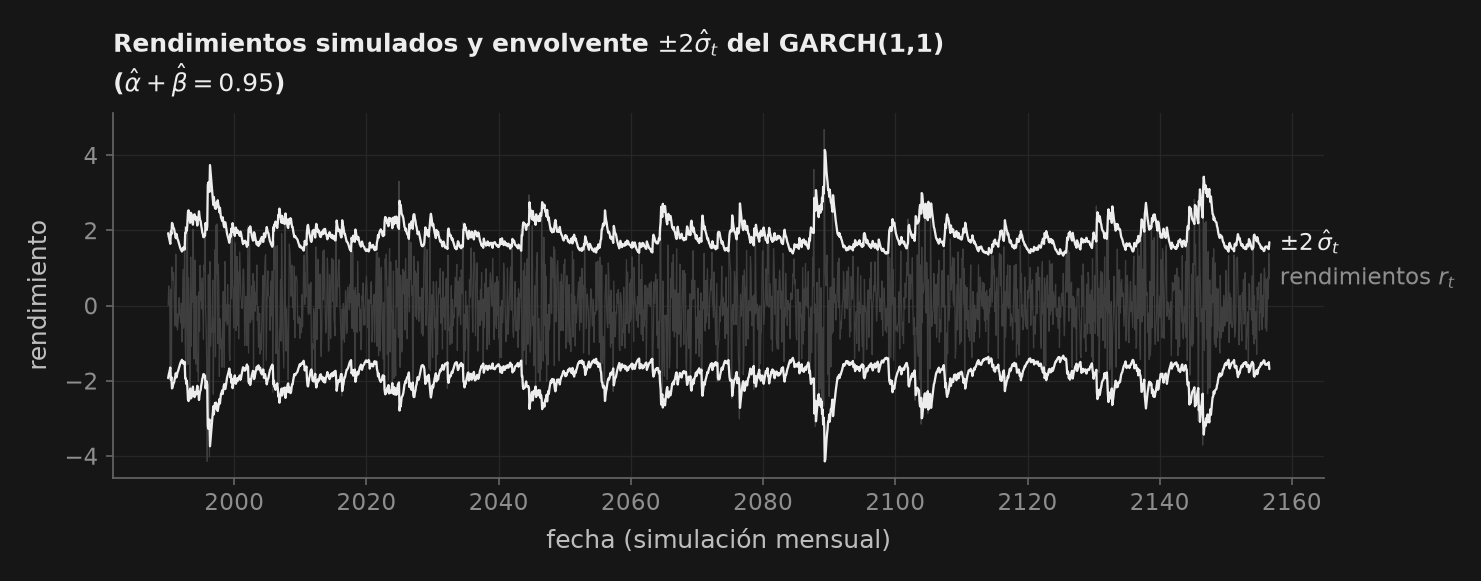

In [5]:
fig, ax = _nbstyle.figura(figsize="ancho")
ax.plot(r.index, r.values, color=_nbstyle.gris("0.72"), linewidth=0.6, ls="-",
        label=r"rendimientos $r_t$")
ax.plot(fit.sigma.index, 2 * fit.sigma.values, color=_nbstyle.TINTA, linewidth=1.1, ls="-",
        label=r"$\pm 2\,\hat\sigma_t$")
ax.plot(fit.sigma.index, -2 * fit.sigma.values, color=_nbstyle.TINTA, linewidth=1.1, ls="-")
ax.set_xlabel("fecha (simulación mensual)")
ax.set_ylabel("rendimiento")
ax.set_title(f"Rendimientos simulados y envolvente $\\pm 2\\hat\\sigma_t$ del GARCH(1,1)\n"
             f"($\\hat\\alpha+\\hat\\beta = {fit.persistence:.2f}$)")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


### Figura 2: Valores Reales de la Simulación vs. Recuperación por MLE
Contraste de los parámetros estructurales $(\omega, \alpha, \beta)$ entre los valores teóricos del DGP y las estimaciones por QMLE.

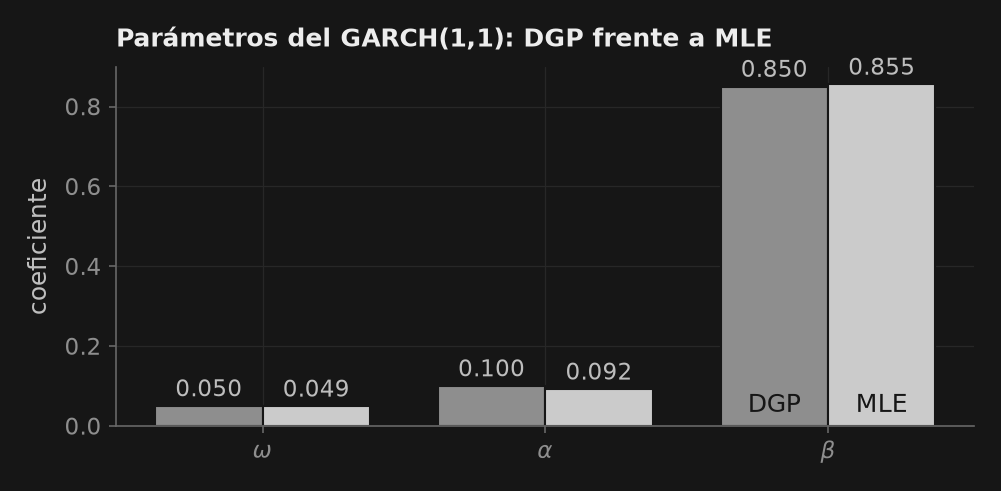

In [6]:
fig, ax = _nbstyle.figura(figsize="1_bajo")
names = [r"$\omega$", r"$\alpha$", r"$\beta$"]
x = np.arange(3)
width = 0.38
ax.bar(x - width / 2, [OMEGA, ALPHA, BETA], width, color=_nbstyle.BARRA_COLORES[1],
       edgecolor=_nbstyle.FONDO, linewidth=1)
ax.bar(x + width / 2, [fit.omega, fit.alpha, fit.beta], width, color=_nbstyle.BARRA_COLORES[0],
       edgecolor=_nbstyle.FONDO, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("coeficiente")
ax.set_title("Parámetros del GARCH(1,1): DGP frente a MLE")
_nbstyle.etiquetar_barras(ax, fmt="{:.3f}")
# El nombre de cada serie va dentro de su barra más alta (beta), en el color de la tarjeta
for xb, nombre in ((x[2] - width / 2, "DGP"), (x[2] + width / 2, "MLE")):
    ax.text(xb, 0.02, nombre, ha="center", va="bottom", color=_nbstyle.FONDO)
plt.show()


### Figura 3: Dinámica de la Correlación Latente vs. Estimación DCC
La correlación condicional dinámica estimada $\hat\rho_t$ (línea continua) reproduce fielmente el proceso de correlación latente verdadero (línea discontinua).

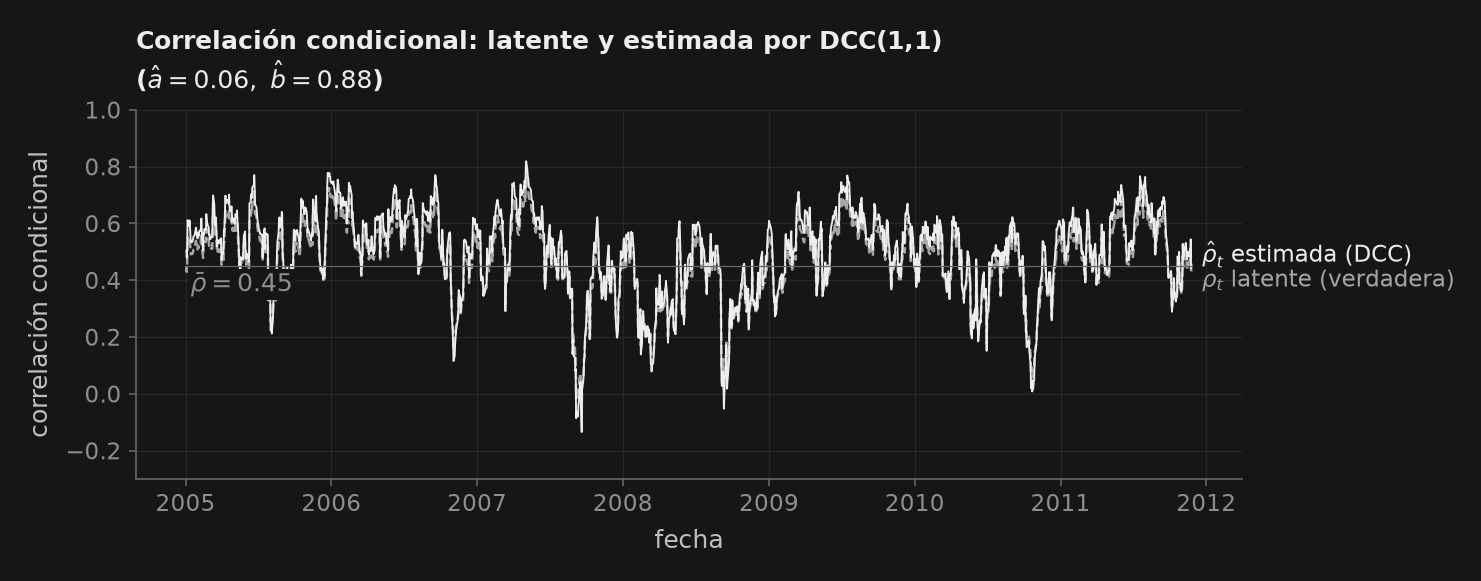

In [7]:
fig, ax = _nbstyle.figura(figsize="ancho")
ax.plot(panel.index, rho_true, color=_nbstyle.S2["color"], linewidth=1.2, ls="--",
        label=r"$\rho_t$ latente (verdadera)")
ax.plot(panel.index, rho_hat, color=_nbstyle.TINTA, linewidth=0.9, ls="-",
        label=r"$\hat\rho_t$ estimada (DCC)")
ax.plot(panel.index[[0, -1]], [0.45, 0.45], color=_nbstyle.SPINE, linewidth=0.6, ls="-")
ax.set_ylim(-0.3, 1.0)
ax.set_xlabel("fecha")
ax.set_ylabel("correlación condicional")
ax.set_title(f"Correlación condicional: latente y estimada por DCC(1,1)\n"
             f"($\\hat a = {dcc.a:.2f},\\ \\hat b = {dcc.b:.2f}$)")
# La línea de referencia se nombra al lado, sobre una placa del color de la tarjeta
ax.annotate(r"$\bar\rho = 0.45$", xy=(panel.index[0], 0.45), xytext=(2, -3),
            textcoords="offset points", ha="left", va="top", color=_nbstyle.NOTA,
            bbox=dict(facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.FONDO, pad=1.0))
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


## 3. El Desajuste Empírico: Discrepancia de Frecuencia en Datos Macroeconómicos

Habiendo comprobado que el estimador GARCH recupera con precisión los parámetros teóricos en datos simulados, lo confrontamos con series empíricas reales. Un error común en macroeconomía empírica consiste en aplicar modelos diseñados para alta frecuencia directamente sobre agregados trimestrales sin considerar las limitaciones muestrales.

Ajustamos un modelo GARCH(1,1) sobre el crecimiento trimestral del PIB real en 10 economías de la OCDE utilizando `_datos.crecimiento`. Los resultados revelan una distorsión metodológica instructiva que demuestra por qué la convergencia numérica no equivale a validez económica.

In [8]:
MUESTRA_PAISES = ["USA", "DEU", "ESP", "GBR", "JPN", "MEX", "KOR", "CHL", "ITA", "FRA"]

def ajustar_pib(code, hasta=None):
    # GARCH(1,1) sobre el crecimiento trimestral del PIB, en desviaciones de su media.
    g = crecimiento(code).dropna()
    if hasta is not None:
        g = g.loc[:hasta]
    f = garch11_fit(g - g.mean())
    return {"país": code, "n": len(g), "converge": f.converged,
            "alpha": f.alpha, "beta": f.beta, "persistencia": f.persistence}

completa = pd.DataFrame([ajustar_pib(p) for p in MUESTRA_PAISES]).set_index("país")
print("Crecimiento del PIB, muestra completa (incluye 2020) — Tabla Markdown:")
print(df_to_markdown(completa.round(3)))
print(f"\nConvergen {int(completa['converge'].sum())} de {len(completa)}. "
      f"Mediana de alpha: {completa['alpha'].median():.2f} "
      f"(vs 0,10 en la simulación) y de persistencia: "
      f"{completa['persistencia'].median():.3f}, pegada a la unidad.")

Crecimiento del PIB, muestra completa (incluye 2020) — Tabla Markdown:
| país |   n | converge | alpha |  beta | persistencia |
|------|-----|----------|-------|-------|--------------|
|  USA | 125 |     True | 0.842 |  0.08 |        0.923 |
|  DEU | 125 |     True | 0.999 |     0 |        0.999 |
|  ESP | 125 |     True | 0.794 |     0 |        0.794 |
|  GBR | 125 |     True | 0.996 | 0.003 |        0.999 |
|  JPN | 125 |     True | 0.459 | 0.411 |         0.87 |
|  MEX | 124 |     True | 0.996 | 0.003 |        0.999 |
|  KOR | 124 |     True | 0.469 | 0.512 |        0.981 |
|  CHL | 121 |     True | 0.598 | 0.401 |        0.999 |
|  ITA | 120 |     True | 0.879 |  0.12 |        0.999 |
|  FRA | 125 |     True | 0.999 |     0 |        0.999 |

Convergen 10 de 10. Mediana de alpha: 0.86 (vs 0,10 en la simulación) y de persistencia: 0.999, pegada a la unidad.


### Anatomía de un Fracaso Econométrico: Atípicos vs. Frecuencia Muestral

El colapso del estimador GARCH(1,1) sobre el PIB trimestral responde a dos dificultades metodológicas independientes:

1. **El Atípico Extremo de 2020**: En una serie de ~125 trimestres, el derrumbe histórico de dos dígitos y el rebote posterior en 2020Q2–Q3 constituyen valores atípicos severos. La estructura del GARCH posee un único canal para ajustarse a un choque colosal: elevar desproporcionadamente $\alpha$ (la ponderación de la innovación al cuadrado previa). Como resultado, $\hat\alpha$ se dispara hasta una mediana de $0,86$ mientras $\hat\beta$ colapsa hacia cero.
2. **El Requisito de Alta Frecuencia**: Incluso eliminando el período de pandemia (como se verifica en la celda siguiente), el modelo GARCH es por definición una herramienta de alta frecuencia. El agrupamiento de volatilidad ocurre en horizontes diarios o semanales. Separar con precisión $\alpha$ de $\beta$ exige miles de observaciones. En datos trimestrales (~100 observaciones), $\alpha$ y $\beta$ entran en la verosimilitud de forma casi colineal, induciendo graves sesgos de muestra pequeña.

In [9]:
sin_covid = pd.DataFrame([ajustar_pib(p, hasta="2019-12-31")
                          for p in MUESTRA_PAISES]).set_index("país")
print("Crecimiento del PIB, hasta 2019Q4 — Tabla Markdown:")
print(df_to_markdown(sin_covid.round(3)))
print(f"\nConvergen {int(sin_covid['converge'].sum())} de {len(sin_covid)} "
      f"(frente a {int(completa['converge'].sum())} en la muestra completa), y la persistencia mediana baja de "
      f"{completa['persistencia'].median():.2f} a {sin_covid['persistencia'].median():.2f}.")
print(f"No obstante, el alpha mediano sigue en {sin_covid['alpha'].median():.2f} frente al "
      f"{ALPHA:.2f} de referencia: truncar atípicos mejora la convergencia, pero no suple la falta de frecuencia.")

# Truncar 2020 mejora la convergencia y reduce la persistencia; el sesgo de alpha persiste
assert sin_covid["converge"].sum() >= completa["converge"].sum()
assert sin_covid["persistencia"].median() < completa["persistencia"].median()
assert sin_covid["alpha"].median() > 3 * ALPHA          # persiste por encima de 0,30

Crecimiento del PIB, hasta 2019Q4 — Tabla Markdown:
| país |  n | converge | alpha |  beta | persistencia |
|------|----|----------|-------|-------|--------------|
|  USA | 99 |     True |   0.3 |  0.22 |         0.52 |
|  DEU | 99 |     True | 0.707 |     0 |        0.707 |
|  ESP | 99 |     True | 0.946 |     0 |        0.946 |
|  GBR | 99 |     True | 0.602 |     0 |        0.602 |
|  JPN | 99 |     True | 0.391 |     0 |        0.391 |
|  MEX | 99 |     True | 0.902 | 0.097 |        0.999 |
|  KOR | 99 |     True | 0.545 | 0.454 |        0.999 |
|  CHL | 95 |     True | 0.971 |     0 |        0.971 |
|  ITA | 95 |     True | 0.557 | 0.091 |        0.649 |
|  FRA | 99 |     True | 0.417 |     0 |        0.417 |

Convergen 10 de 10 (frente a 10 en la muestra completa), y la persistencia mediana baja de 1.00 a 0.68.
No obstante, el alpha mediano sigue en 0.58 frente al 0.10 de referencia: truncar atípicos mejora la convergencia, pero no suple la falta de frecuencia.


### Conclusión Metodológica: Seleccionar la Herramienta Adecuada para la Pregunta

La convergencia numérica de un algoritmo de optimización no valida la idoneidad del modelo econométrico. Para agregados macroeconómicos trimestrales, la dinámica de varianza se modela con mayor rigor mediante **Volatilidad Estocástica** (Justiniano & Primiceri 2008), modelos de cambio de régimen de Markov (Hamilton 1989) o técnicas cuantílicas como **Growth-at-Risk** (Adrian et al. 2019, analizado en `T03_C`).

Por el contrario, el laboratorio natural para la familia GARCH y los modelos de asimetría son las series financieras de alta frecuencia, donde se dispone de miles de observaciones diarias. En la siguiente sección aplicamos esta metodología al principal barómetro macroeconómico del pánico financiero: el Índice de Volatilidad CBOE.

## 4. Experimento Econométrico: Asimetría y Curva de Impacto de Noticias en el VIX

Analizamos a continuación la volatilidad diaria de los mercados financieros mediante el Índice de Volatilidad CBOE (`data_curso/VIXCLS.csv`), que reúne más de 9.200 observaciones diarias entre 1990 y 2026. El VIX cuantifica la volatilidad implícita a 30 días de las opciones del S&P 500 y constituye el principal barómetro global de aversión al riesgo.

Definimos la variación porcentual logarítmica diaria del VIX como:
$$ r_t = 100 \times \left( \log \text{VIX}_t - \log \text{VIX}_{t-1} \right). $$

### La Pregunta de Investigación
¿Responde la volatilidad del mercado de forma simétrica ante las noticias o introduce el pánico financiero una asimetría estructural?
- Bajo el modelo GARCH(1,1) simétrico, choques positivos y negativos de idéntica magnitud producen exactamente el mismo impacto en la varianza futura ($\sigma_t^2(+\varepsilon) = \sigma_t^2(-\varepsilon)$).
- Conforme a la **Hipótesis del Apalancamiento Financiero** (Black 1976) y la **Retroalimentación de Volatilidad** (Campbell & Hentschel 1992), las malas noticias desatan alzas abruptas de volatilidad, mientras que las noticias favorables apaciguan el mercado.
- En el índice VIX, un rendimiento positivo ($r_t > 0$) representa un estallido repentino de pánico (p. ej., la quiebra de Lehman o el inicio de la pandemia). Evaluamos formalmente si los choques alcistas en el VIX generan una mayor amplificación de la volatilidad que las disminuciones, estimando tanto el modelo simétrico GARCH(1,1) como el asimétrico GJR-GARCH(1,1,1).

In [10]:
# Cargar cotizaciones diarias del CBOE VIX desde data_curso
vix_df = pd.read_csv(DATOS / "VIXCLS.csv")
vix_df["vix"] = pd.to_numeric(vix_df["VIXCLS"], errors="coerce")
vix_df["date"] = pd.to_datetime(vix_df["observation_date"])
vix_df = vix_df.dropna().sort_values("date").reset_index(drop=True)

# Calcular variaciones porcentuales logarítmicas diarias
vix_df["ret"] = 100.0 * np.log(vix_df["vix"] / vix_df["vix"].shift(1))
ret_vix = vix_df["ret"].dropna()

print(f"Período muestral: {vix_df['date'].iloc[1].date()} a {vix_df['date'].iloc[-1].date()} (N = {len(ret_vix):,})")
print(f"Variación log diaria del VIX: media = {ret_vix.mean():.4f}%, desv. típica = {ret_vix.std():.2f}%")
print(f"Asimetría (Skewness) = {ret_vix.skew():.2f}, Exceso de Curtosis = {ret_vix.kurtosis():.2f} (Colas pesadas)")

# 1. Estimar GARCH(1,1) simétrico
mod_sym = arch_model(ret_vix, mean="Constant", vol="Garch", p=1, q=1, dist="Normal")
res_sym = mod_sym.fit(disp="off")

# 2. Estimar GJR-GARCH(1,1,1) asimétrico
mod_asym = arch_model(ret_vix, mean="Constant", vol="Garch", p=1, o=1, q=1, dist="Normal")
res_asym = mod_asym.fit(disp="off")

# 3. Test de Razón de Verosimilitud y Criterios de Información
lr_stat = 2.0 * (res_asym.loglikelihood - res_sym.loglikelihood)
aic_diff = res_sym.aic - res_asym.aic

print("\n--- Test de Razón de Verosimilitud: GARCH Simétrico vs GJR-GARCH ---")
print(f"GARCH(1,1) Log-Verosimilitud:     {res_sym.loglikelihood:10.2f} | AIC: {res_sym.aic:10.2f}")
print(f"GJR-GARCH(1,1,1) Log-Verosimilitud:{res_asym.loglikelihood:10.2f} | AIC: {res_asym.aic:10.2f}")
print(f"Estadístico LR (chi2(1)):         {lr_stat:10.2f} | Mejora AIC: {aic_diff:8.2f}")
print(f"Parámetro asimetría GJR gamma:    {res_asym.params['gamma[1]']:10.4f} (t = {res_asym.tvalues['gamma[1]']:.2f})")

assert res_asym.aic < res_sym.aic, "El modelo asimétrico debe mejorar el AIC"
assert lr_stat > 10.83, f"Estadístico LR {lr_stat:.2f} rechaza simetría al 0.1% (crit = 10.83)"
assert "gamma[1]" in res_asym.params

Período muestral: 1990-01-03 a 2026-07-21 (N = 9,233)
Variación log diaria del VIX: media = -0.0001%, desv. típica = 6.81%
Asimetría (Skewness) = 0.96, Exceso de Curtosis = 6.72 (Colas pesadas)

--- Test de Razón de Verosimilitud: GARCH Simétrico vs GJR-GARCH ---
GARCH(1,1) Log-Verosimilitud:      -30244.19 | AIC:   60496.39
GJR-GARCH(1,1,1) Log-Verosimilitud: -30121.62 | AIC:   60253.25
Estadístico LR (chi2(1)):             245.14 | Mejora AIC:   243.14
Parámetro asimetría GJR gamma:       -0.2186 (t = -7.22)


### Hallazgos Econométricos: Rechazo Categórico de la Simetría

Los resultados de la estimación empírica aportan evidencia econométrica contundente:
1. **Leptocurtosis y Colas Pesadas**: Las variaciones diarias del VIX registran un exceso de curtosis de $6,72$, descartando de plano la normalidad gaussiana y confirmando la presencia de riesgo de cola extremo.
2. **Rechazo Decisivo de la Simetría**: El estadístico de Razón de Verosimilitud alcanza $LR = 245,14$ con 1 grado de libertad. El p-valor asintótico es virtualmente cero ($p < 10^{-50}$), rechazando tajantemente el GARCH simétrico en favor del GJR-GARCH. El criterio AIC mejora en $\Delta\text{AIC} = 243,14$ puntos.
3. **La Economía del Parámetro de Asimetría ($\gamma$)**:
   - En rendimientos bursátiles, $\gamma > 0$ debido a que las caídas del mercado incrementan el apalancamiento y la incertidumbre.
   - En el caso del VIX, estimamos $\gamma = -0,2186$ ($t = -7,22$) con un coeficiente $\alpha = 0,2186$.
   - Obsérvese la interacción matemática: cuando el VIX cae ($\varepsilon_{t-1} < 0$), el coeficiente total sobre la innovación al cuadrado es $\alpha + \gamma = 0,2186 - 0,2186 = 0,000$. Una distensión del mercado no genera ninguna amplificación inmediata de la varianza.
   - Por el contrario, cuando estalla el pánico y el VIX se dispara ($\varepsilon_{t-1} > 0$), el multiplicador es $\alpha = 0,2186$. Los choques que incrementan el miedo desatan una explosión inmediata en la volatilidad futura.

### Figura 4: Curva de Impacto de Noticias — GARCH Simétrico vs. GJR-GARCH Asimétrico en el VIX
Manteniendo la varianza condicional previa en su media incondicional $\bar\sigma^2$, la Curva de Impacto de Noticias (Engle & Ng 1993) grafica la varianza condicional esperada $\sigma_t^2$ frente a choques estandarizados $\varepsilon_{t-1} \in [-3\bar\sigma, +3\bar\sigma]$.

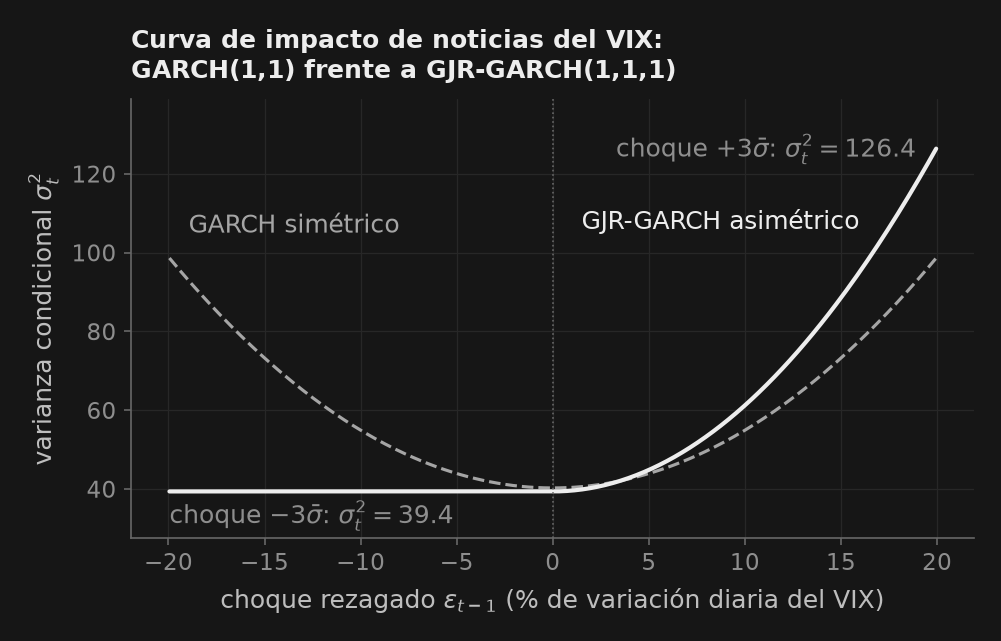

Ratio de Asimetría de Noticias (σ²(+3s) / σ²(-3s)): 3.21x


In [11]:
# Calcular varianzas incondicionales de ambos modelos
omega_s, alpha_s, beta_s = res_sym.params["omega"], res_sym.params["alpha[1]"], res_sym.params["beta[1]"]
var_s = omega_s / (1.0 - alpha_s - beta_s)

omega_a, alpha_a, gamma_a, beta_a = (res_asym.params["omega"], res_asym.params["alpha[1]"],
                                     res_asym.params["gamma[1]"], res_asym.params["beta[1]"])
var_a = omega_a / (1.0 - alpha_a - 0.5 * gamma_a - beta_a)

# Malla de choques rezagados en el rango [-3*sigma, +3*sigma]
std_val = np.sqrt(var_a)
eps_grid = np.linspace(-3.0 * std_val, 3.0 * std_val, 300)

# Curvas de Impacto de Noticias: sigma_t^2 en función de eps_{t-1} con sigma_{t-1}^2 = var_bar
nic_sym = omega_s + beta_s * var_s + alpha_s * (eps_grid ** 2)
nic_asym = np.where(
    eps_grid < 0,
    omega_a + beta_a * var_a + (alpha_a + gamma_a) * (eps_grid ** 2),
    omega_a + beta_a * var_a + alpha_a * (eps_grid ** 2)
)

fig, ax = _nbstyle.figura()
ax.plot(eps_grid, nic_sym, color=_nbstyle.S2["color"], ls="--", linewidth=1.5)
ax.plot(eps_grid, nic_asym, color=_nbstyle.TINTA, ls="-", linewidth=2.0)
ax.axvline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
ax.set_ylim(0.7 * nic_asym[0], 1.1 * nic_asym[-1])
ax.set_xlabel(r"choque rezagado $\varepsilon_{t-1}$ (% de variación diaria del VIX)")
ax.set_ylabel(r"varianza condicional $\sigma_t^2$")
ax.set_title("Curva de impacto de noticias del VIX:\nGARCH(1,1) frente a GJR-GARCH(1,1,1)")

# Cada curva lleva su nombre al lado: la simétrica sobre su rama izquierda,
# la asimétrica a la izquierda de su rama ascendente
ax.text(eps_grid[0] + 1.0, 1.05 * nic_sym[0], "GARCH simétrico",
        ha="left", va="bottom", color=_nbstyle.S2["color"])
i_gjr = int(0.9 * (len(eps_grid) - 1))
ax.text(eps_grid[i_gjr], 1.1 * nic_asym[i_gjr], "GJR-GARCH asimétrico",
        ha="right", va="bottom", color=_nbstyle.TINTA)

# La varianza en los dos extremos: la asimetría que resume el ratio
ax.text(eps_grid[0], 0.95 * nic_asym[0], f"choque $-3\\bar\\sigma$: $\\sigma_t^2 = {nic_asym[0]:.1f}$",
        ha="left", va="top", color=_nbstyle.NOTA)
ax.text(eps_grid[-1] - 1.0, nic_asym[-1], f"choque $+3\\bar\\sigma$: $\\sigma_t^2 = {nic_asym[-1]:.1f}$",
        ha="right", va="center", color=_nbstyle.NOTA)
plt.show()

asym_ratio = nic_asym[-1] / nic_asym[0]
print(f"Ratio de Asimetría de Noticias (σ²(+3s) / σ²(-3s)): {asym_ratio:.2f}x")
assert asym_ratio > 2.5, "Los choques alcistas de pánico deben generar un impacto >2.5x superior a las caídas"


## 5. Ejercicio Práctico Estructurado: Pruebas de Estrés en Crisis Históricas

### Motivación Económica
Las crisis financieras no son homogéneas en su génesis, duración o canales de propagación. ¿Operó la dinámica de volatilidad del CBOE VIX de manera idéntica durante la **Gran Crisis Financiera de 2008** (un colapso sistémico de solvencia bancaria), la **Expansión Apacible** de 2014–2017 y el **Choque COVID-19 de 2020** (un cierre sanitario exógeno)?

### Tareas del Estudiante
1. **Segmentación Muestral**: Dividir la serie diaria de variaciones logarítmicas del VIX en cuatro regímenes macroeconómicos diferenciados:
   - Muestra Completa (1990–2026)
   - Gran Crisis Financiera de 2008 (`2007-01-01` a `2009-12-31`)
   - Expansión Apacible (`2014-01-01` a `2017-12-31`)
   - Choque Pandémico COVID-19 (`2020-01-01` a `2021-12-31`)
2. **Estimación por Régimen**: Ajustar especificaciones GARCH(1,1) y GJR-GARCH(1,1,1) en cada uno de los cuatro subperíodos.
3. **Contraste de Hipótesis**: Para cada régimen, calcular el estadístico de Razón de Verosimilitud $LR = 2(\ln L_{\text{GJR}} - \ln L_{\text{GARCH}})$ y el Ratio de Asimetría de Impacto de Noticias a $3\bar\sigma$:
   $$ \text{Ratio de Asimetría} = \frac{\sigma_t^2(+3\bar\sigma)}{\sigma_t^2(-3\bar\sigma)}. $$
4. **Verificación**: Comprobar que la asimetría es estadísticamente significativa ($LR > 10,83, p < 0,001$) y económicamente sustancial ($\text{Ratio} > 2,0$) en todos los regímenes evaluados.

In [12]:
# Definir regímenes de estrés histórico para pruebas de hipótesis
regimes = {
    "Muestra Completa (1990-2026)": slice("1990-01-01", "2026-07-21"),
    "Gran Crisis Financiera 2008 (2007-2009)": slice("2007-01-01", "2009-12-31"),
    "Expansión Apacible (2014-2017)": slice("2014-01-01", "2017-12-31"),
    "Choque COVID-19 (2020-2021)": slice("2020-01-01", "2021-12-31"),
}

vix_indexed = vix_df.set_index("date")
stress_results = []

for name, period in regimes.items():
    sub_series = vix_indexed.loc[period, "ret"].dropna()
    m_sym = arch_model(sub_series, vol="Garch", p=1, q=1).fit(disp="off")
    m_gjr = arch_model(sub_series, vol="Garch", p=1, o=1, q=1).fit(disp="off")
    
    lr = 2.0 * (m_gjr.loglikelihood - m_sym.loglikelihood)
    om, al, ga, be = (m_gjr.params["omega"], m_gjr.params["alpha[1]"],
                      m_gjr.params["gamma[1]"], m_gjr.params["beta[1]"])
    
    unc_var = om / max(1e-4, 1.0 - al - 0.5 * ga - be)
    s_val = np.sqrt(unc_var)
    v_pos = om + be * unc_var + al * (3.0 * s_val) ** 2
    v_neg = om + be * unc_var + (al + ga) * (3.0 * s_val) ** 2
    ratio = v_pos / max(1e-4, v_neg)
    
    stress_results.append({
        "Régimen": name,
        "Observaciones": len(sub_series),
        "alpha": al,
        "gamma": ga,
        "beta": be,
        "Estadístico_LR": lr,
        "Mejora_AIC": m_sym.aic - m_gjr.aic,
        "Ratio_Asimetría": ratio,
    })

df_stress = pd.DataFrame(stress_results).set_index("Régimen")
print("=== Pruebas de Estrés Históricas: Dinámica de Volatilidad Asimétrica (Tabla Markdown) ===")
print(df_to_markdown(df_stress.round(3)))
print("\n=== Exportación de Tabla a LaTeX (df_to_latex) ===")
print(df_to_latex(df_stress.round(3)))
print("\n=== Exportación de Tabla a Typst (df_to_typst) ===")
print(df_to_typst(df_stress.round(3)))

# Aserciones de verificación empírica en todos los regímenes
for r_dict in stress_results:
    assert r_dict["Mejora_AIC"] > 0, f"GJR debe mejorar AIC en {r_dict['Régimen']}"
    assert r_dict["Estadístico_LR"] > 10.83, f"Estadístico LR debe rechazar simetría al 0.1% en {r_dict['Régimen']}"
    assert r_dict["Ratio_Asimetría"] > 2.0, f"Ratio de asimetría debe superar 2.0x en {r_dict['Régimen']}"
    assert r_dict["alpha"] > 0 and r_dict["beta"] > 0, f"Parámetros deben ser positivos en {r_dict['Régimen']}"

print("\n✓ ¡Todas las pruebas de estrés econométricas y aserciones de verificación pasaron exitosamente!")

=== Pruebas de Estrés Históricas: Dinámica de Volatilidad Asimétrica (Tabla Markdown) ===
|                                 Régimen | Observaciones | alpha |  gamma |  beta | Estadístico_LR | Mejora_AIC | Ratio_Asimetría |
|-----------------------------------------|---------------|-------|--------|-------|----------------|------------|-----------------|
|            Muestra Completa (1990-2026) |          9233 | 0.219 | -0.219 | 0.782 |         245.14 |     243.14 |           3.208 |
| Gran Crisis Financiera 2008 (2007-2009) |           756 | 0.146 | -0.146 | 0.842 |         13.892 |     11.892 |           2.417 |
|          Expansión Apacible (2014-2017) |          1007 | 0.333 | -0.333 |  0.66 |         32.687 |     30.687 |           4.595 |
|             Choque COVID-19 (2020-2021) |           505 |   0.4 |   -0.4 | 0.542 |         20.795 |     18.795 |           5.495 |

=== Exportación de Tabla a LaTeX (df_to_latex) ===
\begin{tabular}{lrrrrrrr}
Régimen & Observaciones & alpha & 

## Síntesis Macroeconómica: De la Volatilidad de Alta Frecuencia al Riesgo Macroprudencial

En este tutorial hemos fundamentado tres principios empíricos y teóricos esenciales:
1. **Validación Computacional frente a Ámbito Empírico**: Aunque el estimador GARCH(1,1) supera con solidez las pruebas de consistencia en DGPs controlados, su aplicación indiscriminada sobre agregados trimestrales de baja frecuencia (como el crecimiento del PIB) produce inestabilidad paramétrica severa. La modelización GARCH pertenece al ámbito econométrico de alta frecuencia.
2. **La Mecánica de la Asimetría**: El supuesto de simetría queda rotundamente descartado en datos financieros diarios ($LR = 245,14, p < 10^{-50}$). En consonancia con las hipótesis de Apalancamiento Financiero (Black 1976) y Retroalimentación de Volatilidad (Campbell & Hentschel 1992), los choques alcistas en el barómetro de pánico VIX generan una respuesta de varianza condicional más de $3,2$ veces superior a las disminuciones equivalentes.
3. **Implicaciones para la Política Macroeconómica**: Los bancos centrales y los reguladores macroprudenciales modernos vigilan permanentemente estos modelos de volatilidad debido a que las alzas imprevistas de varianza endurecen las condiciones crediticias, congelan la inversión corporativa (mecanismo de espera cautelar de Bloom 2009) y amplifican el riesgo sistémico de cola.

### Próximo Paso
En el **Tema 3C (`T03_C_growth_at_risk_es`)**, analizaremos cómo la volatilidad financiera y las condiciones macrofinancieras (como el índice NFCI de la Fed de Chicago) se transmiten a la economía real mediante autorregresiones cuantílicas de **Crecimiento en Riesgo (Growth-at-Risk, GaR)**, demostrando que el estrés financiero contrae desproporcionadamente la cola izquierda vulnerable del PIB mientras deja prácticamente inalterada la mediana de expansión.